# FigGamma3 residuals — net $n=3$ photoionization, $(n_3\Gamma_{\rm Pa}-\alpha_3n_en_p)/\alpha_An_en_p$, vs radius

Twin of FigGamma2_residuals one level up, same inputs and loader. $\Gamma_{\rm Pa}$ is the simulated $n=3$
photoionization rate built from the per-cell Monte-Carlo field over the band from the Paschen edge (8204 Å) past the
Balmer and Lyman edges to the same top as the other two figures, and $\alpha_3(T_e)\,n_en_p$ is the rate that direct
recombination to $n=3$ (3s+3p+3d) alone would balance. The plotted quantity is the excess of $n=3$ photoionization over
direct recombination to $n=3$, normalised to the total recombination rate $\alpha_A(T_e)\,n_en_p$ as in the other two
residual figures. Between 80% and 100% of $\Gamma_{\rm Pa}$ comes from photons between the Paschen and Balmer edges,
so this is a test of the Paschen band alone.

Three levels organise the figure. **$-\alpha_3/\alpha_A\simeq-0.11$** means no Paschen photoionization at all: $n=3$
is fed by recombination and by the cascade and drains radiatively through H$\alpha$, the open-cascade (Case B) picture
for $n\ge3$. **Zero** is bound-free detailed balance for $n=3$, $n_3\Gamma_{\rm Pa}=\alpha_3n_en_p$. The **dashed
reference** $(\alpha_B-\alpha_2-\alpha_3)/\alpha_A$ at each cell's $T_e$ (0.33 at $10^4$ K; $\alpha_2=7.69\times10^{-14}\,T_4^{-0.64}$ and
$\alpha_3=4.55\times10^{-14}\,T_4^{-0.75}\,{\rm cm^3\,s^{-1}}$, power-law fits to Osterbrock & Ferland 2006, Table 2.1) is the analogue of the
Case B line in FigGamma2_residuals: every recombination to $n\ge3$ leaves through $n=3$ photoionization, which requires
the Balmer lines to be radiatively trapped so that the Paschen band, not H$\alpha$, empties the level. The runs move up
this ladder with $\dot M$: mu_m2.5 sits at the floor everywhere, mu_m5 just above it, mu_m10 a quarter of the way to
zero (Paschen photoionization returns three quarters of the direct recombinations to $n=3$, H$\alpha$ the rest), and
mu_m15 climbs through zero to about half the funnel limit just outside its scattering surface before collapsing at the
recombination front. Inside the Lyman transition the residual is negative in every run, as for $n=2$. No Sirocco rate
estimators are used; both quantities come from the spectral output, the level populations and $T_e$.

Vertical markers use the definitions and colours shared with FigOpticalDepth and FigHeatCool: the Lyman radius (blue) is where the inside-out Lyman-continuum absorption depth from the base reaches
$\tau_{\rm LyC}=3$ (`breaks.lyc_transition_radius`; the incident LyC is then attenuated by $e^{-3}$ and ground-state
ionization has handed over to the on-the-spot recombination continuum), and the scattering surface (goldenrod) is where
the outward electron-scattering column from the converged edge reaches $\tau_{\rm es}=1$. The recombination front (red) is
where the hydrogen neutral fraction first reaches $x_{\rm HI}=0.5$ (inside the converged domain only for m5, m10 and m15;
m2.5 stays more than half ionized throughout). All three residual figures
share the $\alpha_An_en_p$ normalisation and the same linear y-range, so their amplitudes can be compared directly.


In [1]:
import os, glob
import numpy as np, pandas as pd
import wind_scales                 # one definition of r_sph (Mdot-dependent)
import breaks                      # one definition of the Lyman transition radius, shared with FigOpticalDepth / FigHeatCool
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.integrate import cumulative_trapezoid as ctz
trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz   # renamed in numpy 2.0; works under both pins

# ================= config: edit here to point at your data / output =================
# Identical to FigGamma1/FigGamma2 -- same runs, same output dir, so the three figures are twins.
DATA_ROOT = os.environ.get("SIROCCO_REPRO_DATA", "/scratch/gpfs/nk6352/sirocco_runs")
FIG_DIR   = os.path.abspath("../figures")           # where this notebook writes its PDF/PNG
RUN_DIRS = {"m2.5": "repro/mu_m2.5", "m5": "repro/mu_m5",
                   "m10": "repro/mu_m10", "m15": "repro/mu_m15"}
def run_path(k): return os.path.join(DATA_ROOT, RUN_DIRS[k])
os.makedirs(FIG_DIR, exist_ok=True)

# ---- manuscript style ----
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'serif', 'mathtext.fontset': 'dejavuserif',
    'font.size': 9, 'axes.titlesize': 10, 'axes.labelsize': 10,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
})

# =====================================================================================
# Minimal machinery -- ONLY what the residual needs.  As in FigGamma1/2_residuals there is no
# level solve and no incident model: n_3(r) comes straight from Sirocco and Gamma_Pa from the
# per-cell MC field.  Diffuse part = alpha_3 n_e n_p / n_3 (on-the-spot closure to n=3).  n=3 is
# fed by direct recombination and by the cascade from n>=4 and drained by Paschen photoionization
# and by H-alpha (and Paschen-line) emission, so the closure is a null hypothesis to be tested.
# =====================================================================================
C=2.998e10; H=6.6261e-27; KB=1.3807e-16; M_P=1.6726e-24; S_T=6.65e-25; X_H=0.71
SIG1=6.30e-18; NU1=C/912e-8                        # H I n=1 edge x-section and Lyman edge freq (as FigGamma1)
SIG2=1.386e-17; NU2=NU1/4.0                        # H I n=2 edge x-section and Balmer edge freq (3646 A)
SIG3=2.153e-17; NU3=NU1/9.0                        # H I n=3 edge x-section and Paschen edge freq (8204 A)
# SIG2, SIG3 are Sirocco's OWN tabulated threshold values (xdata/atomic_macro/h20_phot.dat, first
# PhotMac row of levels 2 and 3: 1.38575e-17 at 3.3996 eV and 2.15278e-17 at 1.51093 eV) -- i.e.
# Kramers x Gaunt (0.877, 0.908), the same true-threshold convention SIG1=6.30e-18 uses for n=1.
# Milne-inverting sig_n(nu)=SIG_n(nu_n/nu)^3 at 1e4 K gives alpha_1 = 1.52e-13, alpha_2 = 7.40e-14
# and alpha_3 = 4.37e-14, i.e. 4% below the exact 1.58e-13, 7.69e-14 and 4.55e-14 for ALL THREE
# levels -- the cross-sections and the recombination coefficients below are consistent to the same
# accuracy, which is what the closure needs.
R_EDD=lambda Mdot: float(wind_scales.r_sph(Mdot))   # spherization radius, Mdot-dependent

# Paschen band: from the Paschen edge PAST the Balmer and Lyman edges to the same top as the
# FigGamma1/2 grids (0.9 dex above the Lyman edge), because Sirocco's Gamma_Pa integrates every
# photon above nu_3.  In practice 80-100% of Gamma_Pa comes from photons between the Paschen and
# Balmer edges (the nu^-3 cross-section), so the band top is immaterial.
NU_TOP = NU1*10**0.9


def aA(T): return 4.18e-13*(T/1e4)**-0.721          # Case-A total recombination coeff [cm^3/s]  (normalisation)
def aB(T): return 2.59e-13*(T/1e4)**-0.833          # Case-B recombination coeff [cm^3/s]
def a2(T): return 7.69e-14*(T/1e4)**-0.64           # recombination DIRECT to n=2 (2s+2p): power-law fit to Osterbrock & Ferland (2006) Table 2.1,
                                                    #   alpha_2s+alpha_2p = 1.170e-13 / 7.69e-14 / 4.84e-14 at 5e3 / 1e4 / 2e4 K (fit within 2%)
def a3(T): return 4.55e-14*(T/1e4)**-0.75           # recombination DIRECT to n=3 (3s+3p+3d): power-law fit to Osterbrock & Ferland (2006) Table 2.1,
                                                    #   sum = 7.73e-14 / 4.55e-14 / 2.71e-14 at 5e3 / 1e4 / 2e4 K (fit within 1%)

def simGamma(J,fr,Nc,lo,hi,sig0,e0):
    "Sirocco's actual Gamma from the per-cell MC field J_nu, over the Paschen band."
    s=(fr>=lo)&(fr<=hi); nu=fr[s]; sig=sig0*(e0/nu)**3; out=np.zeros(Nc); nn=min(Nc,J.shape[0])
    out[:nn]=trapz((4*np.pi*J[:nn][:,s]/(H*nu))*sig,nu,axis=1); return out

def load_run(run_dir):
    "Structure (r, ne, converge, Te, n_p) + Sirocco's n_1(r), n_3(r), its actual Gamma_Pa and the Lyman-transition radius, inwind cells only."
    m=pd.read_csv(f'{run_dir}/outflow.master.txt',sep=r'\s+');     m=m[m['inwind']==0].reset_index(drop=True)
    L=pd.read_csv(f'{run_dir}/outflow.H_1.levden.txt',sep=r'\s+'); L=L[L['inwind']==0].reset_index(drop=True)
    x=pd.read_csv(sorted(glob.glob(f'{run_dir}/outflow.xspec.all*.txt'))[0],sep=r'\s+')
    fr=x['Freq.'].values; cols=[c for c in x.columns if c!='Freq.' and c.startswith('F')]; J=x[cols].values.T
    r=m['r'].values; ne=m['ne'].values; conv=m['converge'].values
    Te=m['t_e'].values; nH=m['rho'].values*X_H/M_P; h1=m['h1'].values; npr=(1.0-h1)*nH   # H I fraction, proton density n_p = n(H II)
    n1=(L['ion_den']*L['lev1']).values                                            # H I n=1 [cm^-3] (transition radius only)
    n3=(L['ion_den']*L['lev3']).values                                            # H I n=3 [cm^-3]
    G3sim=simGamma(J,fr,len(r),NU3,NU_TOP,SIG3,NU3)
    rLy=breaks.lyc_transition_radius(r,n1)                                        # tau_LyC=3 from the base (shared definition)
    return r,ne,conv,n3,G3sim,Te,npr,rLy,h1

def gamma3_recomb(Te,ne,npr,n3):
    "On-the-spot Gamma_Pa = alpha_3(Te) n_e n_p / n_3 (== Gamma_Pa IF n=3 were in photoion. equilibrium)."
    return a3(Te)*ne*npr/n3

# ---- markers shared with FigOpticalDepth / FigHeatCool: same definitions, same colours ----
C_LYB, C_PHOT = 'tab:blue', 'goldenrod'          # Lyman radius (tau_LyC=3 from the base) / scattering surface tau_es=1
def photosphere_radius(r, ne, rmax):
    "Radius where the OUTWARD e-scattering column (r -> converged edge at rmax) = 1 (as FigOpticalDepth)."
    tes     = ctz(ne*S_T, r, initial=0.0)
    edge    = min(int(np.searchsorted(r, rmax)), len(tes) - 1)
    tau_out = tes[edge] - tes
    below   = tau_out <= 1.0
    if below.all() or not below.any():
        return np.nan
    k = int(np.argmax(below))
    return r[0] if k == 0 else float(np.interp(1.0, [tau_out[k], tau_out[k-1]], [r[k], r[k-1]]))
C_FRONT = 'tab:red'                              # recombination front: H neutral fraction x_HI = 0.5
def front_radius(r, h1, x_c=0.5):
    "Recombination front: first radius (outward) where the H I fraction h1 reaches x_c, interpolated in log r; NaN if never."
    above = np.asarray(h1) >= x_c
    if not above.any(): return np.nan
    i = int(np.argmax(above))
    return float(r[0]) if i == 0 else float(np.exp(np.interp(x_c, [h1[i-1], h1[i]], [np.log(r[i-1]), np.log(r[i])])))
vbar = lambda c: Line2D([], [], color=c, marker='|', linestyle='None', markersize=9, markeredgewidth=1.5)  # legend key

RUNS=[('2.5','m2.5',2.5), ('5','m5',5.0), ('10','m10',10.0), ('15','m15',15.0)]


mu_m2.5  beyond Lyman transition: median -0.11, range -0.11 to -0.10;  r_trans/r_sph=38.6, tau_es=1 at r/r_sph=135, x_HI=0.5 at r/r_sph=nan
mu_m5    beyond Lyman transition: median -0.10, range -0.11 to -0.06;  r_trans/r_sph=7.0, tau_es=1 at r/r_sph=144, x_HI=0.5 at r/r_sph=694
mu_m10   beyond Lyman transition: median -0.03, range -0.10 to -0.02;  r_trans/r_sph=2.5, tau_es=1 at r/r_sph=100, x_HI=0.5 at r/r_sph=200
mu_m15   beyond Lyman transition: median -0.01, range -0.09 to +0.16;  r_trans/r_sph=1.6, tau_es=1 at r/r_sph=44, x_HI=0.5 at r/r_sph=61


/tmp/ipykernel_3229568/98464654.py:20: RuntimeWarning: divide by zero encountered in divide
  resid = (n3*G3sim - a3(Te)*rec)/(aA(Te)*rec)     # net n=3 photoionization in units of the total recombination rate


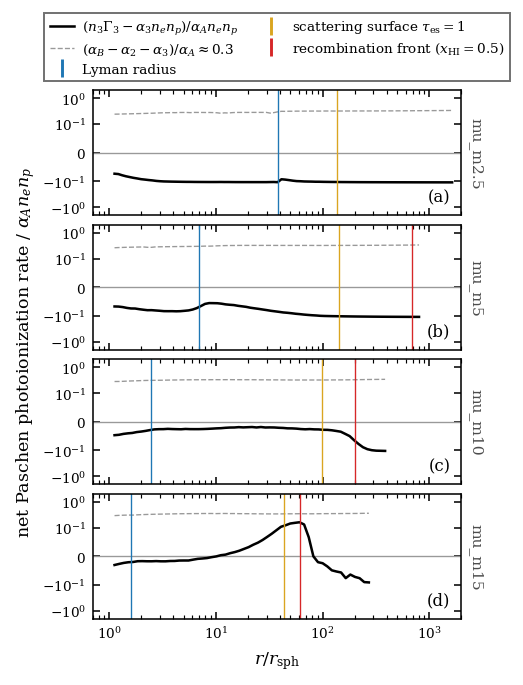

In [2]:
# ---- net n=3 photoionization (n3 Gamma_Pa - alpha_3 n_e n_p) / (alpha_A n_e n_p) vs radius, one panel per run (mu only) ----
# Layout mirrors FigGamma2_residuals; the dashed reference is the n=3 funnel limit (alpha_B - alpha_2 - alpha_3)/alpha_A
# at T_e. Same convergence mask / R_OUT convention. Legend = two-column framed box above panel (a).
CONV_MAX = 2
R_OUT = {}
fig, axes = plt.subplots(len(RUNS), 1, figsize=(3.4, 4.9), sharex=True, gridspec_kw=dict(hspace=0.08))
letters = iter('abcd')
for ax, (lab, key, Mdot) in zip(axes, RUNS):
    r, ne, conv, n3, G3sim, Te, npr, rLy, h1 = load_run(run_path(key))
    G3d   = gamma3_recomb(Te, ne, npr, n3)
    rE    = R_EDD(Mdot); x = r/rE
    ok    = np.where(conv <= CONV_MAX)[0]
    sel   = ok[ok < np.searchsorted(r, R_OUT.get(lab, 1.2e18))]
    rmax  = r[sel[-1]] if len(sel) else r[0]
    msk   = r <= rmax
    cmask = lambda a: np.where(conv[msk] <= CONV_MAX, a[msk], np.nan)
    rPh   = photosphere_radius(r, ne, rmax)
    rFr   = front_radius(r[msk], h1[msk])            # recombination front x_HI=0.5, converged domain only
    rec   = ne*npr
    resid = (n3*G3sim - a3(Te)*rec)/(aA(Te)*rec)     # net n=3 photoionization in units of the total recombination rate
    funnel= (aB(Te) - a2(Te) - a3(Te))/aA(Te)        # every recombination to n>=3 leaves through n=3  ->  (alpha_B - alpha_2 - alpha_3)/alpha_A at T_e
    ax.axhline(0.0,   color='0.6', lw=0.7)
    ax.plot(x[msk], cmask(resid), color='k', lw=1.3, label=r'$(n_3\Gamma_3-\alpha_3 n_en_p)/\alpha_A n_en_p$')
    ax.plot(x[msk], cmask(funnel), color='0.6', lw=0.7, ls='--', label=r'$(\alpha_B-\alpha_2-\alpha_3)/\alpha_A\approx0.3$')
    if np.isfinite(rLy): ax.axvline(rLy/rE, color=C_LYB,  lw=0.7)
    if np.isfinite(rPh): ax.axvline(rPh/rE, color=C_PHOT, lw=0.7)
    if np.isfinite(rFr): ax.axvline(rFr/rE, color=C_FRONT, lw=0.7)
    ax.set_xscale('log'); ax.set_yscale('symlog', linthresh=0.1); ax.set_ylim(-2, 2)                 # linear; same range in all three residual figures
    ax.tick_params(which='both', labelsize=7)
    ax.text(0.97, 0.08, f'({next(letters)})', transform=ax.transAxes, ha='right', va='bottom', fontsize=8.5)
    ax.text(1.02, 0.5, f'mu_m{lab}', transform=ax.transAxes, rotation=270, ha='left', va='center', fontsize=8, color='0.30')   # right-side run label
    ib = int(np.searchsorted(r, rLy)) if np.isfinite(rLy) else 0
    beyond = (np.arange(len(r)) >= ib+2) & msk & (conv <= CONV_MAX)   # skip the transition cell itself
    q = resid[beyond]
    print(f"mu_m{lab:<4s} beyond Lyman transition: median {np.nanmedian(q):+.2f}, range {np.nanmin(q):+.2f} to {np.nanmax(q):+.2f}"
          f";  r_trans/r_sph={rLy/rE:.1f}, tau_es=1 at r/r_sph={rPh/rE:.0f}, x_HI=0.5 at r/r_sph={rFr/rE:.0f}")
h, l = axes[0].get_legend_handles_labels()
axes[0].legend(h+[vbar(C_LYB), vbar(C_PHOT), vbar(C_FRONT)], l+['Lyman radius', r'scattering surface $\tau_{\rm es}=1$', r'recombination front ($x_{\rm HI}{=}0.5$)'],
               ncol=2, loc='lower center', bbox_to_anchor=(0.5, 1.02), frameon=True, fancybox=False, edgecolor='0.3',
               fontsize=7, handlelength=1.8, handletextpad=0.6, columnspacing=1.5, labelspacing=0.4)   # framed box above panel (a)
axes[-1].set_xlabel(r'$r/r_{\rm sph}$', fontsize=9)
fig.supylabel(r'net Paschen photoionization rate / $\alpha_A n_en_p$', fontsize=9, x=-0.04)   # one shared y-label for the four panels
axes[0].set_xlim(0.7, 2e3)
fig.savefig(os.path.join(FIG_DIR, 'FigGamma3_residuals.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'FigGamma3_residuals.png'), dpi=300)
plt.show()
